In [1]:
"""
Script to visualize pseudobulk splicing PSI data from the long format file
"""

# Load packages we need
import pandas as pd
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Set, Dict, Any, Optional
from scipy import stats
from sklearn.decomposition import PCA
import gffutils
import random
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Alternatively, you can directly specify the path
module_path = "/gpfs/commons/home/kisaev/LeafletFA-utils"

# Add path if not already in sys.path
if module_path not in sys.path:
    sys.path.append(module_path)
    print(f"Added {module_path} to sys.path")

# Now you should be able to import from leafletfa_utils
from leafletfa_utils.atsemapper.main import run_atsemapper # type: ignore
from leafletfa_utils.atseviz.main import * # type: ignore
print("Imports successful!")

# ----- Configuration -----

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

# Output directory
output_dir = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/visualizations"
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {output_dir}")

# Timestamp for file naming
timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Imports successful!
Output directory: /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/visualizations


In [2]:
# ----- Load data -----
pseudobulk_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/112025/pseudobulk_final_tissue_celltype_20260105_171037.csv.gz"
print(f"Loading pseudobulk data from: {pseudobulk_file}")
long_df = pd.read_csv(pseudobulk_file, low_memory=False)
print(f"Loaded {len(long_df)} rows of data with {long_df['cell_type'].nunique()} cell types")

# Load ATSE data
ATSE_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-10-01_21-36-40.txt.gz"
atses = pd.read_csv(ATSE_file, sep="\t")
print(f"Loaded {len(atses)} rows of ATSE data with {len(atses['event_id'].unique())} unique events")

db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/ATSE_mapper/genomes/lr_GRCm38.db"
db = gffutils.FeatureDB(db_file, keep_order=True)
genome_db_available = True

Loading pseudobulk data from: /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/112025/pseudobulk_final_tissue_celltype_20260105_171037.csv.gz
Loaded 14103467 rows of data with 157 cell types
Loaded 113995 rows of ATSE data with 32567 unique events


#### Input: Gene ID or symbol and output: Clustermap output with all gene-junctions-ATSEs displayed PSI by major cell type group

In [3]:
# filter rows where n_cells==0
long_df = long_df[long_df["n_cells"] > 0]

In [5]:
long_df["junction_id"].nunique(), long_df["cell_type"].nunique(), long_df["gene_id"].nunique()

(89831, 128, 10572)

In [6]:
# filter rows where gene_symbol is NaN
long_df = long_df[long_df["gene_symbol"].notna()]

In [7]:
long_df["gene_id"] = long_df["gene_id"].str.split(".").str[0]

In [11]:
long_df

,cell_type,junction_id,junction_id_index,junction_count,atse_count,gene_symbol,psi,n_cells,gene_id,event_id
1,Liver_T cell,chr3_108123837_108145887_-,50611,1470.0,1470.0,GNAI3,1.000000,253,ENSMUSG00000000001,ENSMUSG00000000001.4_atse_1
2,Aorta_Endothelial cell,chr3_108123837_108145887_-,50611,1182.0,1182.0,GNAI3,1.000000,329,ENSMUSG00000000001,ENSMUSG00000000001.4_atse_1
3,Aorta_Endothelial cell,chr3_108123837_108149094_-,50612,0.0,1182.0,GNAI3,0.000000,329,ENSMUSG00000000001,ENSMUSG00000000001.4_atse_1
4,Bladder_Bladder epithelial cell,chr3_108123837_108145887_-,50611,1448.0,1448.0,GNAI3,1.000000,521,ENSMUSG00000000001,ENSMUSG00000000001.4_atse_1
5,Pancreas_Endothelial cell,chr3_108123837_108149094_-,50612,0.0,507.0,GNAI3,0.000000,147,ENSMUSG00000000001,ENSMUSG00000000001.4_atse_1
...,...,...,...,...,...,...,...,...,...,...
14103457,Brain_Microglia,chr18_36676477_36676616_-,33047,2256.0,4227.0,APBB3,0.533712,12042,ENSMUSG00000117679,ENSMUSG00000117679.1_atse_3
14103459,Bladder_Urogenital epithelial cell,chr18_36676477_36676864_-,33048,1.0,257.0,APBB3,0.003891,1008,ENSMUSG00000117679,ENSMUSG00000117679.1_atse_3
14103460,Trachea_T cell,chr18_36676622_36676864_-,33049,22.0,67.0,APBB3,0.328358,253,ENSMUSG00000117679,ENSMUSG00000117679.1_atse_3
14103461,Trachea_T cell,chr18_36676477_36676864_-,33048,0.0,67.0,APBB3,0.000000,253,ENSMUSG00000117679,ENSMUSG00000117679.1_atse_3


In [8]:
long_df["cell_type"].unique()

array(['Liver_T cell', 'Aorta_Endothelial cell',
       'Bladder_Bladder epithelial cell', 'Pancreas_Endothelial cell',
       'MAT_B cell', 'Marrow_B cell', 'Marrow_Granulocyte',
       'Diaphragm_Endothelial cell', 'MAT_Mesenchymal stem cell',
       'BAT_T cell', 'Heart_Macrophage', 'GAT_Endothelial cell',
       'Kidney_B cell', 'Kidney_T cell',
       'Marrow_Hematopoietic progenitor', 'Brain_Endothelial cell',
       'BAT_B cell', 'Lung_B cell', 'Spleen_T cell', 'GAT_B cell',
       'Liver_Hepatocyte', 'Brain_Other neuron',
       'Mammary_Gland_Mammary epithelial cell',
       'Pancreas_Pancreatic endocrine cell', 'Brain_Oligodendrocyte',
       'Lung_Dendritic cell', 'Brain_Microglia',
       'BAT_Other epithelial cell', 'Heart_T cell',
       'Spleen_Hematopoietic progenitor', 'Aorta_Fibroblast',
       'Mammary_Gland_Stromal cell', 'Liver_B cell',
       'Kidney_Kidney epithelial cell',
       'Bladder_Urogenital epithelial cell', 'Trachea_Endothelial cell',
       'Limb_Musc

In [12]:
long_df[long_df["gene_id"] == "ENSMUSG00000024109"]

,cell_type,junction_id,junction_id_index,junction_count,atse_count,gene_symbol,psi,n_cells,gene_id,event_id
3798772,Lung_Fibroblast,chr17_90704367_90991366_-,32294,0.0,0.0,NRXN1,NaN,489,ENSMUSG00000024109,ENSMUSG00000024109.18_atse_1
3798773,Diaphragm_B cell,chr17_90704367_90992114_-,32295,0.0,0.0,NRXN1,NaN,90,ENSMUSG00000024109,ENSMUSG00000024109.18_atse_1
3798775,GAT_Mesenchymal stem cell,chr17_90704367_90991366_-,32294,0.0,0.0,NRXN1,NaN,1285,ENSMUSG00000024109,ENSMUSG00000024109.18_atse_1
3798776,GAT_Mesenchymal stem cell,chr17_90704367_91087954_-,32296,0.0,0.0,NRXN1,NaN,1285,ENSMUSG00000024109,ENSMUSG00000024109.18_atse_1
3798777,Diaphragm_B cell,chr17_90704367_90991366_-,32294,0.0,0.0,NRXN1,NaN,90,ENSMUSG00000024109,ENSMUSG00000024109.18_atse_1
...,...,...,...,...,...,...,...,...,...,...
3802378,Brain_Oligodendrocyte,chr17_90037384_90059484_-,32272,684.0,1640.0,NRXN1,0.417073,1360,ENSMUSG00000024109,ENSMUSG00000024109.18_atse_8
3802379,Marrow_Granulocyte,chr17_90037384_90059475_-,32271,1.0,1.0,NRXN1,1.000000,2653,ENSMUSG00000024109,ENSMUSG00000024109.18_atse_8
3802380,Brain_Inhibitory neuron,chr17_90037384_90059475_-,32271,155506.0,287088.0,NRXN1,0.541667,17259,ENSMUSG00000024109,ENSMUSG00000024109.18_atse_8
3802381,Aorta_Other immune cell,chr17_90037384_90059475_-,32271,0.0,0.0,NRXN1,NaN,96,ENSMUSG00000024109,ENSMUSG00000024109.18_atse_8


                         cell_type                junction_id  \
3798772            Lung_Fibroblast  chr17_90704367_90991366_-   
3798773           Diaphragm_B cell  chr17_90704367_90992114_-   
3798775  GAT_Mesenchymal stem cell  chr17_90704367_90991366_-   
3798776  GAT_Mesenchymal stem cell  chr17_90704367_91087954_-   
3798777           Diaphragm_B cell  chr17_90704367_90991366_-   
...                            ...                        ...   
3802378      Brain_Oligodendrocyte  chr17_90037384_90059484_-   
3802379         Marrow_Granulocyte  chr17_90037384_90059475_-   
3802380    Brain_Inhibitory neuron  chr17_90037384_90059475_-   
3802381    Aorta_Other immune cell  chr17_90037384_90059475_-   
3802382    Brain_Inhibitory neuron  chr17_90037384_90059484_-   

         junction_id_index  junction_count  atse_count gene_symbol       psi  \
3798772              32294             0.0         0.0       NRXN1       NaN   
3798773              32295             0.0         0.0     

/scratch/ipykernel_2764964/926578611.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis').copy()


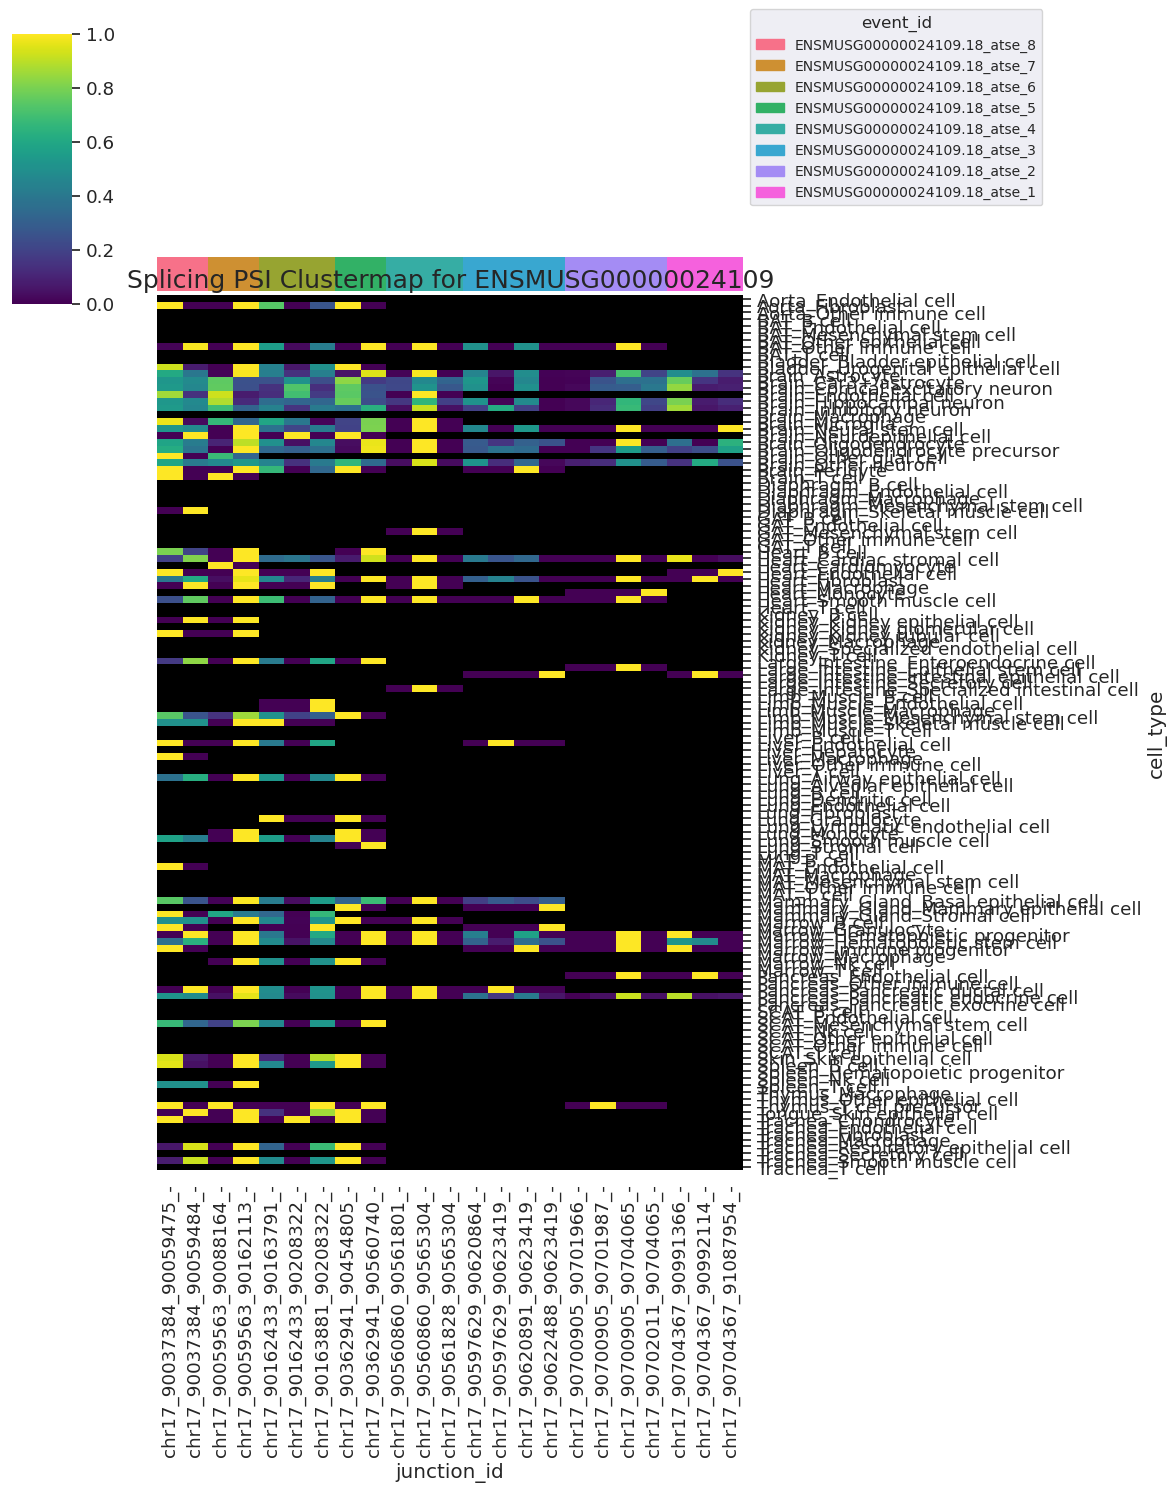

In [13]:
# Sample gene name from your dataset
# gene_name = np.random.choice(long_df["gene_symbol"].unique(), 1)[0]
gene_id = "ENSMUSG00000024109"
gene_vals = long_df[long_df["gene_id"] == gene_id]
print(gene_vals)

# Pivot to create a matrix: rows = cell types, columns = junctions, values = PSI
psi_matrix = gene_vals.pivot(index='cell_type', columns='junction_id', values='psi')

# --- Leave NaNs as they are, do not fill with 0 ---
# psi_matrix = psi_matrix.fillna(0)

# Map junctions to event_ids
junction_to_event = gene_vals.drop_duplicates(subset='junction_id')[['junction_id', 'event_id']]
junction_to_event = junction_to_event.set_index('junction_id')['event_id']

# Create a color palette for event IDs
unique_events = junction_to_event.loc[psi_matrix.columns].unique()
event_palette = sns.color_palette("husl", len(unique_events))
event_lut = dict(zip(unique_events, event_palette))

# Color annotation per junction
col_colors = psi_matrix.columns.map(junction_to_event).map(event_lut)

# Set global font scale
sns.set(font_scale=1.2)

# --- Get the colormap and set the color for NaN values ---
# By default, seaborn uses the 'viridis' colormap. We'll make a copy and modify it.
# You can replace 'viridis' with any other colormap you prefer.
cmap = cm.get_cmap('viridis').copy()
cmap.set_bad('black')

# Generate the clustermap
g = sns.clustermap(
    psi_matrix,
    row_cluster=False,
    col_cluster=False,
    cmap=cmap,  # Use the modified colormap
    col_colors=col_colors,
    figsize=(12, 15),
    xticklabels=True,
    yticklabels=True
)

# Add title with gene name
g.ax_heatmap.set_title(f"Splicing PSI Clustermap for {gene_id}", fontsize=18)

# Add legend for event_ids to the right of the heatmap
from matplotlib.patches import Patch
handles = [Patch(color=event_lut[eid], label=eid) for eid in unique_events]
g.ax_col_dendrogram.legend(
    handles=handles,
    title='event_id',
    bbox_to_anchor=(1.0, 1.1),
    loc='upper left',
    fontsize=10,
    title_fontsize=12
)

plt.show()

                         cell_type                junction_id  \
3798772            Lung_Fibroblast  chr17_90704367_90991366_-   
3798773           Diaphragm_B cell  chr17_90704367_90992114_-   
3798775  GAT_Mesenchymal stem cell  chr17_90704367_90991366_-   
3798776  GAT_Mesenchymal stem cell  chr17_90704367_91087954_-   
3798777           Diaphragm_B cell  chr17_90704367_90991366_-   
...                            ...                        ...   
3802378      Brain_Oligodendrocyte  chr17_90037384_90059484_-   
3802379         Marrow_Granulocyte  chr17_90037384_90059475_-   
3802380    Brain_Inhibitory neuron  chr17_90037384_90059475_-   
3802381    Aorta_Other immune cell  chr17_90037384_90059475_-   
3802382    Brain_Inhibitory neuron  chr17_90037384_90059484_-   

         junction_id_index  junction_count  atse_count gene_symbol       psi  \
3798772              32294             0.0         0.0       NRXN1       NaN   
3798773              32295             0.0         0.0     

/scratch/ipykernel_2764964/1567874773.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis').copy()


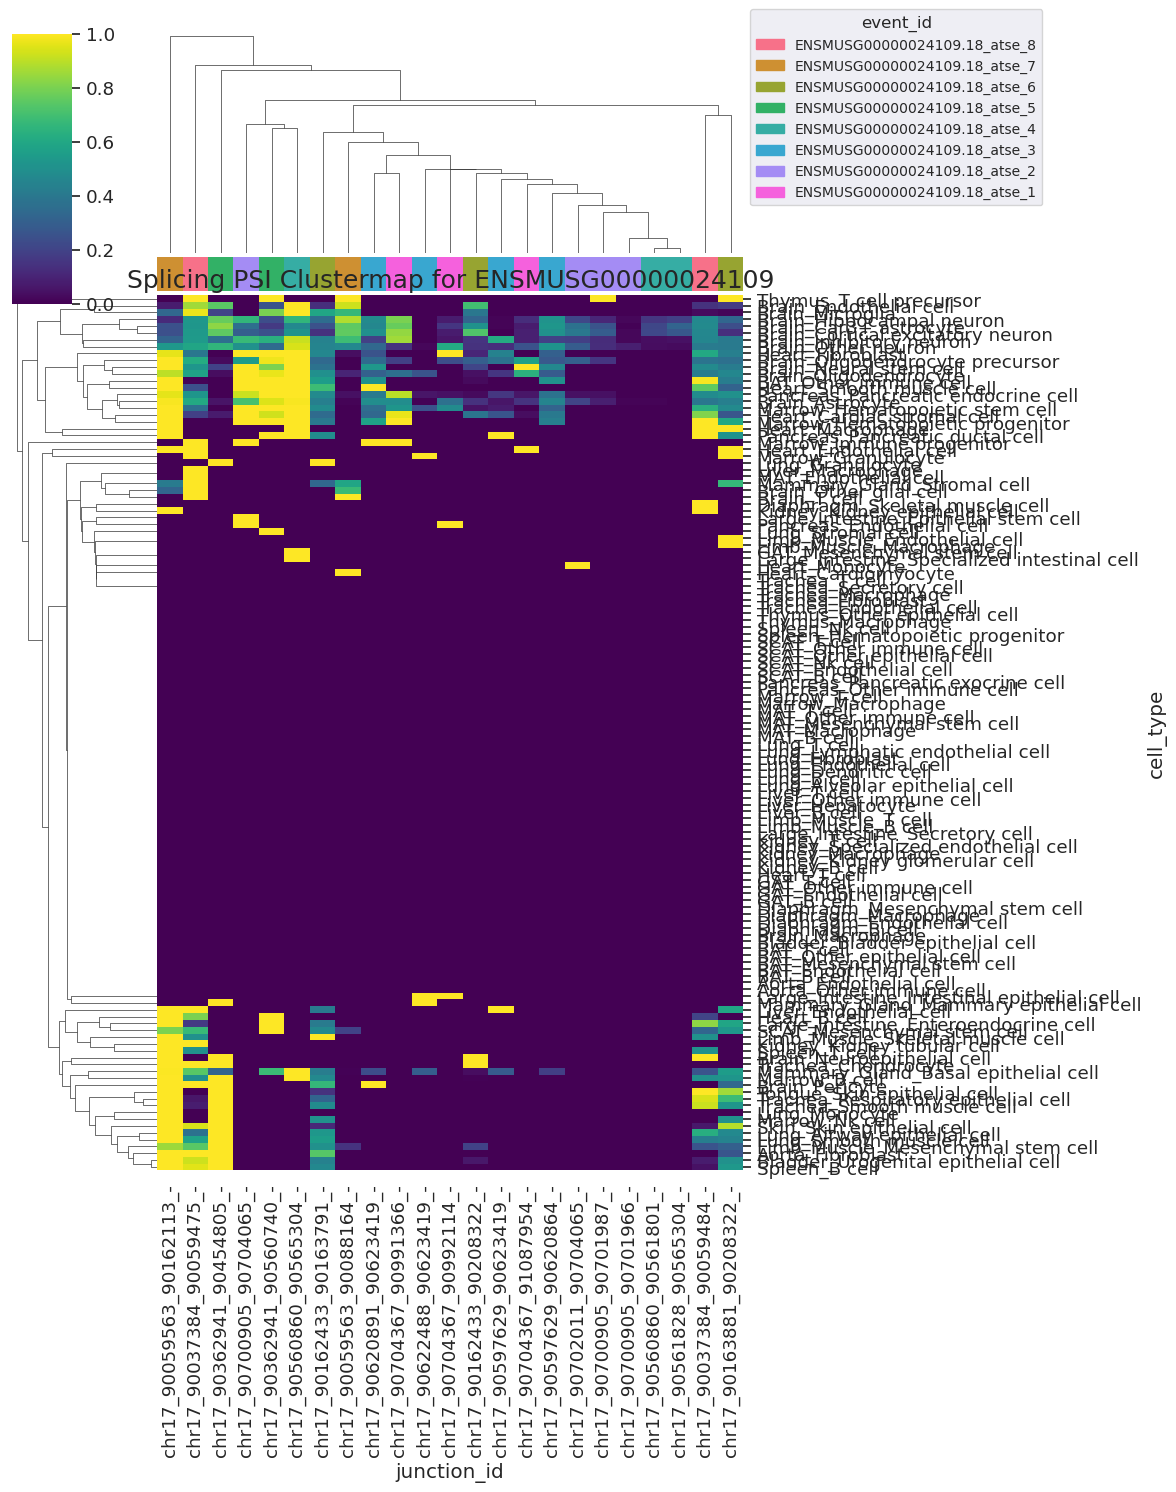

In [14]:
gene_vals = long_df[long_df["gene_id"] == gene_id]
print(gene_vals)

# Pivot to create a matrix: rows = cell types, columns = junctions, values = PSI
psi_matrix = gene_vals.pivot(index='cell_type', columns='junction_id', values='psi')

# Fill NaNs with 0
psi_matrix = psi_matrix.fillna(0)

# Map junctions to event_ids
junction_to_event = gene_vals.drop_duplicates(subset='junction_id')[['junction_id', 'event_id']]
junction_to_event = junction_to_event.set_index('junction_id')['event_id']

# Create a color palette for event IDs
unique_events = junction_to_event.loc[psi_matrix.columns].unique()
event_palette = sns.color_palette("husl", len(unique_events))
event_lut = dict(zip(unique_events, event_palette))

# Color annotation per junction
col_colors = psi_matrix.columns.map(junction_to_event).map(event_lut)

# Set global font scale
sns.set(font_scale=1.2)

# Get the colormap
cmap = cm.get_cmap('viridis').copy()

# Generate the clustermap WITH CLUSTERING
g = sns.clustermap(
    psi_matrix,
    row_cluster=True,  # Enable clustering
    col_cluster=True,  # Enable clustering
    cmap=cmap,
    col_colors=col_colors,
    figsize=(12, 15),
    xticklabels=True,
    yticklabels=True
)

# Add title with gene name
g.ax_heatmap.set_title(f"Splicing PSI Clustermap for {gene_id}", fontsize=18)

# Add legend for event_ids to the right of the heatmap
from matplotlib.patches import Patch
handles = [Patch(color=event_lut[eid], label=eid) for eid in unique_events]
g.ax_col_dendrogram.legend(
    handles=handles,
    title='event_id',
    bbox_to_anchor=(1.0, 1.1),
    loc='upper left',
    fontsize=10,
    title_fontsize=12
)

plt.show()